# Europe's Aging Population — Data Analysis
**Data Visualization Project | MSc Data Science @ UNIMIB**

This notebook is structured in two main sections:
1. **EDA on Datasets** — loading, cleaning and exploring all 6 Eurostat datasets
2. **Graphic Part** — producing all charts for the presentation

---
# EDA on Datasets

## Setup — Imports & Constants

In [1]:
import pandas as pd
import numpy as np
import os

# EU27 country codes
eu27 = ['AT','BE','BG','CY','CZ','DE','DK','EE','EL','ES',
        'FI','FR','HR','HU','IE','IT','LT','LU','LV','MT',
        'NL','PL','PT','RO','SE','SI','SK']

# Shared helper: parse Eurostat TSV — splits key column, strips spaces, cleans flags
def load_eurostat(filepath, key_cols):
    df = pd.read_csv(filepath, sep='\t', header=0)
    df.rename(columns={df.columns[0]: 'key'}, inplace=True)
    df[key_cols] = df['key'].str.split(',', expand=True)
    df.drop(columns=['key'], inplace=True)
    df.columns = df.columns.str.strip()
    cols = key_cols + [c for c in df.columns if c not in key_cols]
    df = df[cols]
    year_cols = [c for c in df.columns if c.isdigit()]
    df[year_cols] = df[year_cols].apply(
        lambda col: pd.to_numeric(
            col.astype(str).str.replace(r'[a-zA-Z\s]', '', regex=True), errors='coerce'))
    return df, year_cols

# Shared helper: wide → long format
def to_long(df_wide, id_col, value_name):
    year_cols = [c for c in df_wide.columns if c.isdigit()]
    df_long = df_wide.melt(id_vars=[id_col], value_vars=year_cols,
                           var_name='year', value_name=value_name)
    df_long['year'] = df_long['year'].astype(int)
    return df_long.sort_values([id_col, 'year']).reset_index(drop=True)

os.makedirs('Dataset1', exist_ok=True)
os.makedirs('Dataset2', exist_ok=True)
os.makedirs('Dataset3', exist_ok=True)
os.makedirs('Dataset4', exist_ok=True)
os.makedirs('Dataset5', exist_ok=True)
os.makedirs('Dataset6', exist_ok=True)
os.makedirs('CSV_Datawrapper', exist_ok=True)
os.makedirs('Grafici_Draft/Mappe', exist_ok=True)

print('✅ Setup complete')

✅ Setup complete


## Dataset 1 — Median Age & Dependency Ratio (`demo_pjanind`)

Indicators: `MEDAGEPOP`, `FMEDAGEPOP`, `MMEDAGEPOP`, `DEPRATIO3`

In [2]:
df, year_cols = load_eurostat(
    'demo_pjanind__custom_20635679_tabular.tsv',
    ['freq', 'indic_de', 'geo']
)
df = df[df['geo'].isin(eu27)]
print(df.shape)
print('\nIndicators:', df['indic_de'].unique())
print('Countries:', df['geo'].nunique())
print('\nSample (MEDAGEPOP, 2000-2023):')
print(df[df['indic_de']=='MEDAGEPOP'][['geo','2000','2010','2023']].head(5))

(108, 69)

Indicators: ['DEPRATIO3' 'FMEDAGEPOP' 'MEDAGEPOP' 'MMEDAGEPOP']
Countries: 27

Sample (MEDAGEPOP, 2000-2023):
    geo  2000  2010  2023
97   AT  37.9  41.6  43.5
99   BE  38.7  40.9  41.9
100  BG  39.1  42.2  46.8
103  CY  33.3  35.6  40.2
104  CZ  37.3  39.6  43.7


In [3]:
# Separate indicators and convert to long format
df_median = df[df['indic_de'] == 'MEDAGEPOP'].copy()
df_dep    = df[df['indic_de'] == 'DEPRATIO3'].copy()
df_fmed   = df[df['indic_de'] == 'FMEDAGEPOP'].copy()
df_mmed   = df[df['indic_de'] == 'MMEDAGEPOP'].copy()

long_median = to_long(df_median, 'geo', 'median_age')
long_dep    = to_long(df_dep,    'geo', 'dep_ratio')
long_fmed   = to_long(df_fmed,   'geo', 'median_age_f')
long_mmed   = to_long(df_mmed,   'geo', 'median_age_m')

# Merge into single clean dataframe
df_clean = (long_median
    .merge(long_dep,  on=['geo','year'], how='left')
    .merge(long_fmed, on=['geo','year'], how='left')
    .merge(long_mmed, on=['geo','year'], how='left'))
df_clean['gender_gap'] = df_clean['median_age_f'] - df_clean['median_age_m']

print('Shape:', df_clean.shape)
print('\nMissing values:')
print(df_clean.isnull().sum())

Shape: (1782, 7)

Missing values:
geo               0
year              0
median_age      202
dep_ratio       200
median_age_f    200
median_age_m    202
gender_gap      202
dtype: int64


In [4]:
# Snapshot: latest available year per country
snapshot_rows = []
for geo in eu27:
    sub = df_clean[df_clean['geo'] == geo].dropna(subset=['median_age'])
    if sub.empty: continue
    row = sub.loc[sub['year'].idxmax()]
    snapshot_rows.append({
        'geo': geo, 'latest_year': row['year'],
        'median_age': row['median_age'], 'dep_ratio': row['dep_ratio'],
        'median_age_f': row['median_age_f'], 'median_age_m': row['median_age_m'],
        'gender_gap': row['gender_gap']
    })
snapshot = pd.DataFrame(snapshot_rows).sort_values('median_age', ascending=False)
print(snapshot[['geo','latest_year','median_age','dep_ratio']].to_string(index=False))

geo  latest_year  median_age  dep_ratio
 IT         2025        49.1       71.3
 BG         2025        47.3       75.6
 PT         2025        47.3       72.1
 EL         2025        47.2       72.2
 ES         2025        45.8       64.3
 SI         2025        45.5       71.6
 DE         2025        45.5       70.6
 HR         2025        45.5       72.8
 HU         2025        44.8       67.8
 LV         2025        44.4       73.7
 CZ         2025        44.3       72.0
 LT         2025        44.3       66.6
 RO         2025        44.1       71.0
 AT         2025        43.8       65.1
 FI         2025        43.5       78.0
 PL         2025        43.4       69.4
 SK         2025        43.0       65.8
 EE         2025        42.9       73.2
 FR         2025        42.8       80.6
 NL         2025        42.6       70.7
 DK         2025        42.2       73.2
 BE         2025        42.1       73.1
 SE         2025        41.2       77.1
 CY         2025        41.0       62.2


In [5]:
# EU27 trend over time
eu27_trend = df_clean.groupby('year')[['median_age','dep_ratio']].mean().reset_index().dropna(subset=['median_age'])
print('--- EU27 TREND ---')
print(eu27_trend[eu27_trend['year'].isin([1960,1970,1980,1990,2000,2010,2020,2025])].to_string(index=False))

# Change 1990 → 2025 by country
print('\n--- CHANGE 1990→2025 ---')
for geo in eu27:
    sub = df_clean[df_clean['geo'] == geo]
    v1 = sub[sub['year']==1990]['median_age'].values
    v2 = sub[sub['year']==2025]['median_age'].values
    if len(v1)>0 and len(v2)>0 and not np.isnan(v1[0]) and not np.isnan(v2[0]):
        print(f"{geo}: {v1[0]:.1f} → {v2[0]:.1f} (+{v2[0]-v1[0]:.1f})")

--- EU27 TREND ---
 year  median_age  dep_ratio
 1960   31.455556  76.694444
 1970   31.990909  78.200000
 1980   32.552174  76.326087
 1990   34.552000  69.516000
 2000   37.230769  65.223077
 2010   40.188889  62.170370
 2020   42.881481  67.522222
 2025   43.814815  69.948148

--- CHANGE 1990→2025 ---
AT: 35.6 → 43.8 (+8.2)
BE: 36.2 → 42.1 (+5.9)
BG: 36.5 → 47.3 (+10.8)
CY: 30.5 → 41.0 (+10.5)
CZ: 35.1 → 44.3 (+9.2)
DE: 38.1 → 45.5 (+7.4)
DK: 37.0 → 42.2 (+5.2)
EE: 34.2 → 42.9 (+8.7)
EL: 36.0 → 47.2 (+11.2)
ES: 33.4 → 45.8 (+12.4)
FI: 36.3 → 43.5 (+7.2)
HU: 36.1 → 44.8 (+8.7)
IE: 29.1 → 39.6 (+10.5)
IT: 36.9 → 49.1 (+12.2)
LT: 32.4 → 44.3 (+11.9)
LU: 36.3 → 39.8 (+3.5)
LV: 34.6 → 44.4 (+9.8)
MT: 32.8 → 40.0 (+7.2)
NL: 34.4 → 42.6 (+8.2)
PL: 32.2 → 43.4 (+11.2)
PT: 33.9 → 47.3 (+13.4)
RO: 32.6 → 44.1 (+11.5)
SE: 38.4 → 41.2 (+2.8)
SI: 34.0 → 45.5 (+11.5)
SK: 31.2 → 43.0 (+11.8)


In [6]:
# Save
df_clean.to_csv('Dataset1/dataset1_pjanind_clean.csv', index=False)
snapshot.to_csv('Dataset1/dataset1_snapshot.csv', index=False)
eu27_trend.to_csv('Dataset1/eu27_trend.csv', index=False)
trend_highlight = df_clean[df_clean['geo'].isin(['IT','DE','FR','ES','BG','IE'])]
trend_highlight.to_csv('Dataset1/trend_highlight.csv', index=False)
print('✅ Dataset1 saved')

✅ Dataset1 saved


## Dataset 2 — Population by Age Group (`demo_pjangroup`)

Used to build the EU27 population pyramid (2001 vs 2023).

In [7]:
df2, year_cols2 = load_eurostat(
    'demo_pjangroup__custom_20635831_tabular.tsv',
    ['freq', 'unit', 'sex', 'age', 'geo']
)
print(df2.shape)
print('Sex:', df2['sex'].unique())
print('Age groups:', sorted(df2['age'].unique()))

(3027, 71)
Sex: ['F' 'M' 'T']
Age groups: ['TOTAL', 'Y10-14', 'Y15-19', 'Y20-24', 'Y25-29', 'Y30-34', 'Y35-39', 'Y40-44', 'Y45-49', 'Y5-9', 'Y50-54', 'Y55-59', 'Y60-64', 'Y65-69', 'Y70-74', 'Y75-79', 'Y80-84', 'Y_GE75', 'Y_GE80', 'Y_GE85', 'Y_LT5']


In [8]:
age_order = ['Y_LT5','Y5-9','Y10-14','Y15-19','Y20-24','Y25-29',
             'Y30-34','Y35-39','Y40-44','Y45-49','Y50-54','Y55-59',
             'Y60-64','Y65-69','Y70-74','Y75-79','Y80-84']
age_labels = ['0-4','5-9','10-14','15-19','20-24','25-29',
              '30-34','35-39','40-44','45-49','50-54','55-59',
              '60-64','65-69','70-74','75-79','80-84']
age_label_map = dict(zip(age_order, age_labels))

# Filter: EU27_2020 aggregate, total sex, 5-year age groups only
df2_filt = df2[
    (df2['geo'].isin(eu27 + ['EU27_2020'])) &
    (df2['sex'] == 'T') &
    (df2['age'].isin(age_order))
].copy()

print('Filtered shape:', df2_filt.shape)

Filtered shape: (476, 71)


In [9]:
# Check data availability for EU27_2020
pyramid_eu27 = df2_filt[df2_filt['geo'] == 'EU27_2020'].copy()

# First valid year per age group
first_valid = {}
for age in age_order:
    row = pyramid_eu27[pyramid_eu27['age'] == age]
    if not row.empty:
        for yr in sorted(year_cols2):
            val = row[yr].values[0]
            if pd.notna(val):
                first_valid[age] = yr
                break
print('First valid year for EU27_2020:', set(first_valid.values()))
# → Data starts from 2001, so we compare 2001 vs 2023

First valid year for EU27_2020: {'2001'}


In [10]:
# Build pyramid long format: 2001 vs 2023
pyramid_long = pyramid_eu27.melt(
    id_vars=['geo','age'], value_vars=year_cols2,
    var_name='year', value_name='population')
pyramid_long['year'] = pyramid_long['year'].astype(int)
pyramid_long = pyramid_long[pyramid_long['year'].isin([2001, 2023])].dropna(subset=['population'])
pyramid_long['population_M'] = pyramid_long['population'] / 1_000_000
pyramid_long['age_label'] = pyramid_long['age'].map(age_label_map)
pyramid_long['age_order'] = pyramid_long['age'].map({a:i for i,a in enumerate(age_order)})
pyramid_long = pyramid_long.sort_values(['year','age_order'])

print(pyramid_long[['age_label','year','population_M']].to_string(index=False))

age_label  year  population_M
      0-4  2001     22.107432
      5-9  2001     23.602387
    10-14  2001     26.223520
    15-19  2001     27.485083
    20-24  2001     29.377961
    25-29  2001     30.880557
    30-34  2001     32.715552
    35-39  2001     32.747875
    40-44  2001     31.618558
    45-49  2001     29.975777
    50-54  2001     28.367883
    55-59  2001     23.015564
    60-64  2001     23.256024
    65-69  2001     20.738605
    70-74  2001     18.293601
    75-79  2001     14.340098
    80-84  2001      7.335421
      0-4  2023     20.376638
      5-9  2023     22.368579
    10-14  2023     23.687811
    15-19  2023     23.470956
    20-24  2023     23.881146
    25-29  2023     25.125533
    30-34  2023     28.032579
    35-39  2023     29.169289
    40-44  2023     30.682229
    45-49  2023     31.358798
    50-54  2023     32.218543
    55-59  2023     32.064605
    60-64  2023     29.751412
    65-69  2023     26.904579
    70-74  2023     23.689644
    75-79 

In [11]:
# Summary: young vs old shares
for yr in [2001, 2023]:
    sub = pyramid_long[pyramid_long['year'] == yr]
    young = sub[sub['age_label'].isin(['0-4','5-9','10-14','15-19','20-24'])]['population_M'].sum()
    old   = sub[sub['age_label'].isin(['65-69','70-74','75-79','80-84'])]['population_M'].sum()
    total = sub['population_M'].sum()
    print(f'\n--- {yr} ---')
    print(f'Young (0-24): {young:.1f}M ({young/total*100:.1f}%)')
    print(f'Old   (65+):  {old:.1f}M  ({old/total*100:.1f}%)')
    print(f'Total:        {total:.1f}M')

pyramid_long.to_csv('Dataset2/pyramid_eu27_2001_2023.csv', index=False)
print('\n✅ Dataset2 saved')


--- 2001 ---
Young (0-24): 128.8M (30.5%)
Old   (65+):  60.7M  (14.4%)
Total:        422.1M

--- 2023 ---
Young (0-24): 113.8M (26.2%)
Old   (65+):  82.2M  (18.9%)
Total:        434.4M

✅ Dataset2 saved


## Dataset 3 — Total Fertility Rate (`demo_find`)

Indicator: `TOTFERRT` — Total Fertility Rate per EU27 country, 1960–2022.

In [12]:
df3, year_cols3 = load_eurostat(
    'demo_find__custom_20635897_tabular.tsv',
    ['freq', 'indic_de', 'geo']
)
df3 = df3[df3['geo'].isin(eu27)].copy()
long_fert = to_long(df3, 'geo', 'fertility_rate')

# 2022 snapshot
fert_2022 = long_fert[long_fert['year']==2022].dropna().sort_values('fertility_rate')
print('--- FERTILITY RATE 2022 ---')
print(fert_2022[['geo','fertility_rate']].to_string(index=False))
print(f'\nEU27 average: {fert_2022["fertility_rate"].mean():.2f}')
print(f'Countries above replacement (2.1): {(fert_2022["fertility_rate"] >= 2.1).sum()}')

--- FERTILITY RATE 2022 ---
geo  fertility_rate
 MT            1.08
 ES            1.16
 IT            1.24
 LT            1.27
 PL            1.29
 LU            1.31
 FI            1.32
 EL            1.32
 CY            1.37
 AT            1.41
 EE            1.41
 PT            1.43
 DE            1.46
 LV            1.47
 NL            1.49
 IE            1.51
 HR            1.53
 SE            1.53
 BE            1.53
 DK            1.55
 SI            1.55
 HU            1.57
 SK            1.57
 CZ            1.64
 RO            1.71
 BG            1.78
 FR            1.78

EU27 average: 1.45
Countries above replacement (2.1): 0


In [13]:
# EU27 trend
eu27_fert_trend = long_fert.groupby('year')['fertility_rate'].mean().reset_index().dropna()
below = eu27_fert_trend[eu27_fert_trend['fertility_rate'] < 2.1]
print(f'First year below replacement threshold: {below["year"].min()}')
print()
print(eu27_fert_trend[eu27_fert_trend['year'].isin([1960,1970,1980,1990,2000,2010,2015,2020,2022])].to_string(index=False))

long_fert.to_csv('Dataset3/fertility_clean.csv', index=False)
eu27_fert_trend.to_csv('Dataset3/fertility_eu27_trend.csv', index=False)
print('\n✅ Dataset3 saved')

First year below replacement threshold: 1978

 year  fertility_rate
 1960        2.596000
 1970        2.321765
 1980        1.981500
 1990        1.790000
 2000        1.472308
 2010        1.587037
 2015        1.546667
 2020        1.512222
 2022        1.454815

✅ Dataset3 saved


## Dataset 4 — Life Expectancy at Birth (`demo_mlexpec`)

Sex: Total | Age: at birth (`Y_LT1`)

In [14]:
df4, year_cols4 = load_eurostat(
    'demo_mlexpec__custom_20635946_tabular.tsv',
    ['freq', 'unit', 'sex', 'age', 'geo']
)
df4 = df4[df4['geo'].isin(eu27)].copy()
long_life = to_long(df4, 'geo', 'life_expectancy')

# Latest available per country
latest_life = (long_life.dropna(subset=['life_expectancy'])
               .loc[lambda x: x.groupby('geo')['year'].transform('max') == x['year']])
print('--- LIFE EXPECTANCY (latest year) ---')
print(latest_life[['geo','year','life_expectancy']].sort_values('life_expectancy', ascending=False).to_string(index=False))
print(f'\nEU27 avg: {latest_life["life_expectancy"].mean():.1f}')
print(f'Max: {latest_life["life_expectancy"].max():.1f} ({latest_life.loc[latest_life["life_expectancy"].idxmax(),"geo"]})')
print(f'Min: {latest_life["life_expectancy"].min():.1f} ({latest_life.loc[latest_life["life_expectancy"].idxmin(),"geo"]})')

--- LIFE EXPECTANCY (latest year) ---
geo  year  life_expectancy
 ES  2024             84.0
 SE  2024             83.8
 IT  2024             83.7
 CY  2024             83.5
 LU  2024             83.2
 IE  2024             83.1
 FR  2024             83.0
 MT  2024             83.0
 PT  2024             82.5
 BE  2024             82.4
 FI  2024             82.2
 AT  2024             82.1
 SI  2024             82.1
 DK  2024             82.0
 EL  2024             81.9
 NL  2024             81.9
 DE  2024             81.2
 CZ  2024             80.1
 EE  2024             79.4
 HR  2024             78.9
 PL  2024             78.5
 SK  2024             78.4
 LT  2024             77.5
 HU  2024             76.8
 RO  2024             76.5
 LV  2024             76.4
 BG  2024             75.8

EU27 avg: 80.9
Max: 84.0 (ES)
Min: 75.8 (BG)


In [15]:
# EU27 trend + COVID impact
eu27_life_trend = long_life.groupby('year')['life_expectancy'].mean().reset_index().dropna()
v1960 = eu27_life_trend[eu27_life_trend['year']==1960]['life_expectancy'].values[0]
v2024 = eu27_life_trend[eu27_life_trend['year']==2024]['life_expectancy'].values[0]
v2019 = eu27_life_trend[eu27_life_trend['year']==2019]['life_expectancy'].values[0]
v2020 = eu27_life_trend[eu27_life_trend['year']==2020]['life_expectancy'].values[0]
print(f'Gain 1960→2024: +{v2024-v1960:.1f} years')
print(f'COVID impact (2019→2020): {v2020-v2019:.1f} years')

long_life.to_csv('Dataset4/life_expectancy_clean.csv', index=False)
eu27_life_trend.to_csv('Dataset4/life_expectancy_eu27_trend.csv', index=False)
print('\n✅ Dataset4 saved')

Gain 1960→2024: +12.1 years
COVID impact (2019→2020): -0.8 years

✅ Dataset4 saved


## Dataset 5 — Pension Expenditure (`spr_exp_pens`)

Filter: `spdepb=OLD`, `unit=PC_GDP` (% of GDP)

In [16]:
df5, year_cols5 = load_eurostat(
    'spr_exp_pens__custom_20636089_tabular.tsv',
    ['freq', 'spdepb', 'spdepm', 'unit', 'geo']
)
df5 = df5[(df5['geo'].isin(eu27)) & (df5['unit'] == 'PC_GDP')].copy()
long_pension = to_long(df5, 'geo', 'pension_pct_gdp')

latest_pension = (long_pension.dropna(subset=['pension_pct_gdp'])
                  .loc[lambda x: x.groupby('geo')['year'].transform('max') == x['year']])
print('--- PENSION EXPENDITURE % GDP (latest year) ---')
print(latest_pension[['geo','year','pension_pct_gdp']].sort_values('pension_pct_gdp', ascending=False).to_string(index=False))
print(f'\nEU27 avg: {latest_pension["pension_pct_gdp"].mean():.1f}%')

--- PENSION EXPENDITURE % GDP (latest year) ---
geo  year  pension_pct_gdp
 FR  2023            12.07
 AT  2023            11.36
 EL  2023            11.31
 FI  2023            11.28
 IT  2023            10.73
 PT  2023             9.55
 SE  2023             9.36
 BE  2023             9.28
 ES  2023             9.12
 DE  2023             8.85
 NL  2023             8.69
 DK  2023             8.67
 PL  2023             8.51
 SI  2023             7.62
 CZ  2023             7.57
 BG  2023             7.56
 LV  2023             7.24
 RO  2023             7.20
 SK  2023             6.63
 LU  2023             5.79
 CY  2023             5.79
 HU  2023             5.75
 LT  2023             5.70
 HR  2023             4.94
 EE  2023             4.83
 MT  2023             4.06
 IE  2023             3.40

EU27 avg: 7.9%


In [17]:
# Trend + country changes
eu27_pension_trend = long_pension.groupby('year')['pension_pct_gdp'].mean().reset_index().dropna()
print(eu27_pension_trend[eu27_pension_trend['year'].isin([1995,2000,2005,2010,2015,2020,2023])].to_string(index=False))

print('\n--- CHANGE OVER TIME ---')
for geo in ['IT','FR','DE','ES','EL','IE']:
    sub = long_pension[long_pension['geo']==geo].dropna()
    if sub.empty: continue
    first, last = sub.iloc[0], sub.iloc[-1]
    print(f"{geo}: {first['year']} ({first['pension_pct_gdp']:.1f}%) → {last['year']} ({last['pension_pct_gdp']:.1f}%) Δ{last['pension_pct_gdp']-first['pension_pct_gdp']:+.1f}%")

long_pension.to_csv('Dataset5/pension_clean.csv', index=False)
latest_pension.to_csv('Dataset5/pension_snapshot.csv', index=False)
print('\n✅ Dataset5 saved')

 year  pension_pct_gdp
 1995         6.778824
 2000         6.581600
 2005         6.467308
 2010         7.558519
 2015         8.008148
 2020         8.465926
 2023         7.883704

--- CHANGE OVER TIME ---
IT: 1995 (6.9%) → 2023 (10.7%) Δ+3.9%
FR: 1990 (8.7%) → 2023 (12.1%) Δ+3.3%
DE: 1991 (6.6%) → 2023 (8.8%) Δ+2.3%
ES: 1995 (7.2%) → 2023 (9.1%) Δ+1.9%
EL: 1995 (6.4%) → 2023 (11.3%) Δ+4.9%
IE: 1995 (2.4%) → 2023 (3.4%) Δ+1.0%

✅ Dataset5 saved


## Dataset 6 — Demographic Balance: Natural Growth & Net Migration (`demo_gind`)

Indicators: `NATGROW` (absolute), `CNMIGRATRT` (rate per 1,000).
Natural growth is converted to a rate using population totals from Dataset 2.

In [18]:
df6, year_cols6 = load_eurostat(
    'demo_gind__custom_20636130_tabular.tsv',
    ['freq', 'indic_de', 'geo']
)
df6 = df6[df6['geo'].isin(eu27)].copy()

long_mig = to_long(df6[df6['indic_de']=='CNMIGRATRT'].copy(), 'geo', 'net_migration_rate')
long_nat = to_long(df6[df6['indic_de']=='NATGROW'].copy(),    'geo', 'natural_growth')

print('Net migration rate sample (IT):')
print(long_mig[long_mig['geo']=='IT'].tail(6).to_string(index=False))
print('\nNatural growth (absolute) sample (IT):')
print(long_nat[long_nat['geo']=='IT'].tail(6).to_string(index=False))

Net migration rate sample (IT):
geo  year  net_migration_rate
 IT  2020                -1.2
 IT  2021                 1.6
 IT  2022                 4.9
 IT  2023                 4.5
 IT  2024                 4.1
 IT  2025                 NaN

Natural growth (absolute) sample (IT):
geo  year  natural_growth
 IT  2020       -335425.0
 IT  2021       -301097.0
 IT  2022       -321744.0
 IT  2023       -291175.0
 IT  2024       -280665.0
 IT  2025             NaN


In [19]:
# Convert natural growth (absolute) → rate per 1,000 using population from Dataset 2
pop = df2[
    (df2['age'] == 'TOTAL') & (df2['sex'] == 'T') & (df2['geo'].isin(eu27))
].copy()
year_cols_pop = [c for c in pop.columns if c.isdigit()]
pop[year_cols_pop] = pop[year_cols_pop].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(r'[a-zA-Z\s]', '', regex=True), errors='coerce'))
pop_long = pop.melt(id_vars=['geo'], value_vars=year_cols_pop, var_name='year', value_name='population')
pop_long['year'] = pop_long['year'].astype(int)
pop_long = pop_long.dropna(subset=['population'])

long_nat_rate = long_nat.merge(pop_long, on=['geo','year'], how='left')
long_nat_rate['natural_growth_rate'] = long_nat_rate['natural_growth'] / long_nat_rate['population'] * 1000

long_demo = long_mig.merge(long_nat_rate[['geo','year','natural_growth_rate']], on=['geo','year'], how='outer')
long_demo['total_growth_rate'] = long_demo['net_migration_rate'] + long_demo['natural_growth_rate']

print('Verification (IT):')
print(long_demo[long_demo['geo']=='IT'][['year','net_migration_rate','natural_growth_rate','total_growth_rate']].tail(8).to_string(index=False))

Verification (IT):
 year  net_migration_rate  natural_growth_rate  total_growth_rate
 2018                 1.2            -3.226446          -2.026446
 2019                 0.7            -3.583165          -2.883165
 2020                -1.2            -5.624021          -6.824021
 2021                 1.6            -5.082989          -3.482989
 2022                 4.9            -5.450504          -0.550504
 2023                 4.5            -4.935404          -0.435404
 2024                 4.1            -4.759355          -0.659355
 2025                 NaN                  NaN                NaN


In [20]:
# Snapshot: latest year per country
snapshot_demo = (long_demo.dropna(subset=['natural_growth_rate','net_migration_rate'])
                 .loc[lambda x: x.groupby('geo')['year'].transform('max') == x['year']])

print('--- NATURAL GROWTH vs MIGRATION (latest year) ---')
print(snapshot_demo[['geo','year','natural_growth_rate','net_migration_rate','total_growth_rate']]
      .sort_values('natural_growth_rate').to_string(index=False))

neg = (snapshot_demo['natural_growth_rate'] < 0).sum()
saved = ((snapshot_demo['total_growth_rate']>0) & (snapshot_demo['natural_growth_rate']<0)).sum()
print(f'\nCountries with NEGATIVE natural growth: {neg}/27')
print(f'Countries saved by migration: {saved}')

long_demo.to_csv('Dataset6/migration_natural_clean.csv', index=False)
snapshot_demo.to_csv('Dataset6/migration_snapshot.csv', index=False)
print('\n✅ Dataset6 saved')

--- NATURAL GROWTH vs MIGRATION (latest year) ---
geo  year  natural_growth_rate  net_migration_rate  total_growth_rate
 LV  2024            -7.358370                -2.5          -9.858370
 BG  2024            -7.339716                 6.1          -1.239716
 LT  2024            -6.364412                 8.0           1.635588
 EL  2024            -5.551784                 6.4           0.848216
 RO  2024            -5.340480                 3.7          -1.640480
 HU  2024            -5.134368                 0.4          -4.734368
 HR  2024            -4.922621                 8.1           3.177379
 IT  2024            -4.759355                 4.1          -0.659355
 EE  2024            -4.412641                 1.0          -3.412641
 PL  2024            -4.279570                 0.9          -3.379570
 DE  2024            -3.961858                 5.4           1.438142
 PT  2024            -3.170382                13.4          10.229618
 FI  2024            -2.595893          

---
# Graphic Part

## Setup — Palette & Style

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

C_DARK  = '#1C2951'
C_MID   = '#4A6480'
C_LIGHT = '#8FA5B8'
C_GOLD  = '#B8902A'
C_RED   = '#8B2A2A'
C_CREAM = '#F5F2ED'

sns.set_style('whitegrid')
plt.rcParams.update({
    'font.family': 'Georgia',
    'axes.facecolor': C_CREAM,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('✅ Palette ready')

✅ Palette ready


## Median Age Bar Chart — EU27 Countries (2025)

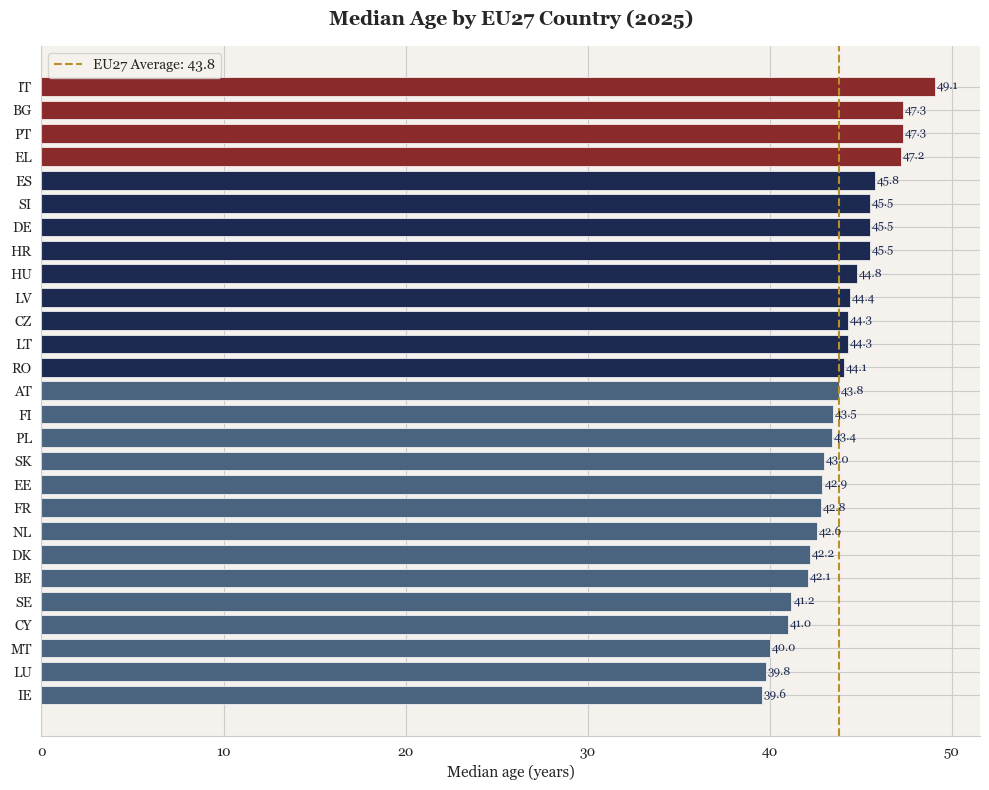

✅ Chart 1 saved


In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
snap = snapshot.sort_values('median_age', ascending=True)
colors = [C_RED if v >= 47 else C_DARK if v >= 44 else C_MID for v in snap['median_age']]
bars = ax.barh(snap['geo'], snap['median_age'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(x=snap['median_age'].mean(), color=C_GOLD, linestyle='--', linewidth=1.5,
           label=f"EU27 Average: {snap['median_age'].mean():.1f}")
ax.set_xlabel('Median age (years)', fontsize=11)
ax.set_title('Median Age by EU27 Country (2025)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
for bar, val in zip(bars, snap['median_age']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8.5, color=C_DARK)
plt.tight_layout()
plt.savefig('Grafici_Draft/01_median_age_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved')

## Median Age Trend — EU27 1960–2025

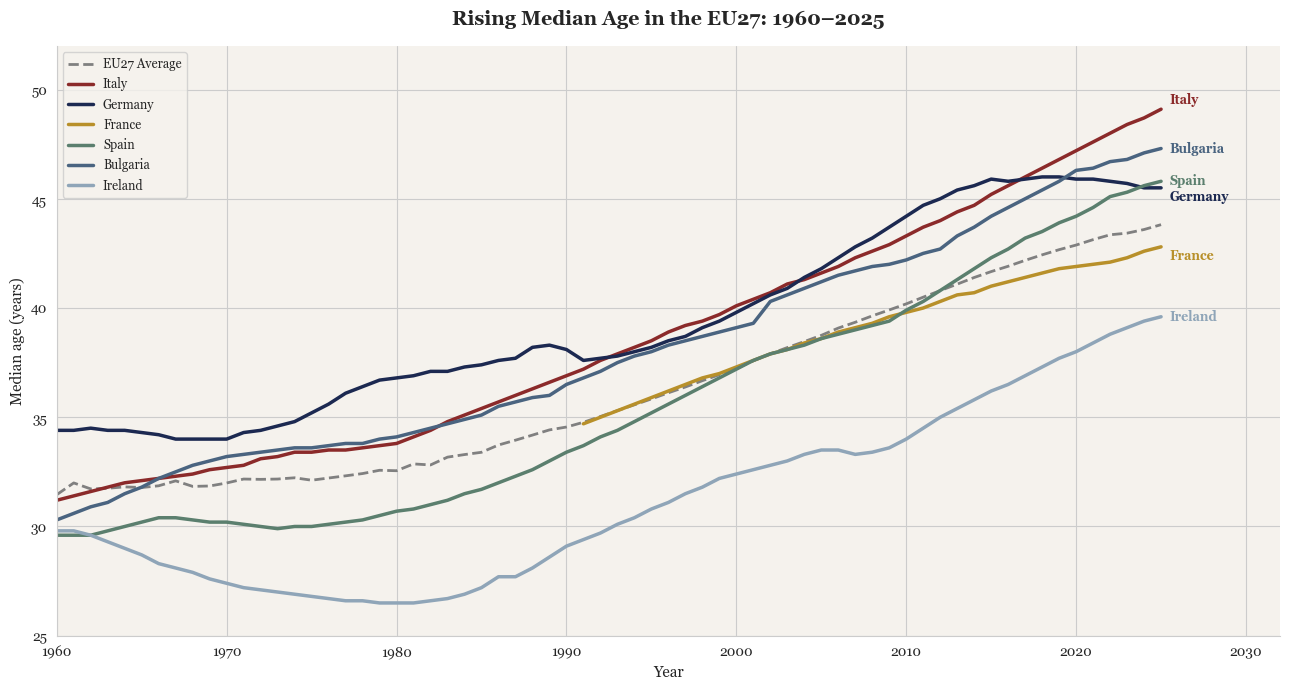

✅ Chart 2 saved


In [23]:
fig, ax = plt.subplots(figsize=(13, 7))
highlight_countries = {
    'IT': (C_RED,     'Italy'),
    'DE': (C_DARK,    'Germany'),
    'FR': (C_GOLD,    'France'),
    'ES': ('#5B7F6E', 'Spain'),
    'BG': (C_MID,     'Bulgaria'),
    'IE': (C_LIGHT,   'Ireland'),
}
label_offsets = {'IT':+0.4, 'DE':-0.4, 'BG':0.0, 'ES':0.0, 'FR':-0.4, 'IE':0.0}

ax.plot(eu27_trend['year'], eu27_trend['median_age'],
        color='gray', linewidth=2, linestyle='--', label='EU27 Average', zorder=1)

for geo, (color, label) in highlight_countries.items():
    sub = df_clean[df_clean['geo']==geo].dropna(subset=['median_age'])
    ax.plot(sub['year'], sub['median_age'], color=color, linewidth=2.5, label=label, zorder=2)
    last = sub.iloc[-1]
    ax.text(last['year']+0.5, last['median_age']+label_offsets[geo],
            label, fontsize=9, color=color, va='center', fontweight='bold')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Median age (years)', fontsize=11)
ax.set_title('Rising Median Age in the EU27: 1960–2025', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(1960, 2032)
ax.set_ylim(25, 52)
plt.tight_layout()
plt.savefig('Grafici_Draft/02_median_age_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved')

## Population Pyramid — EU27 2001 vs 2023

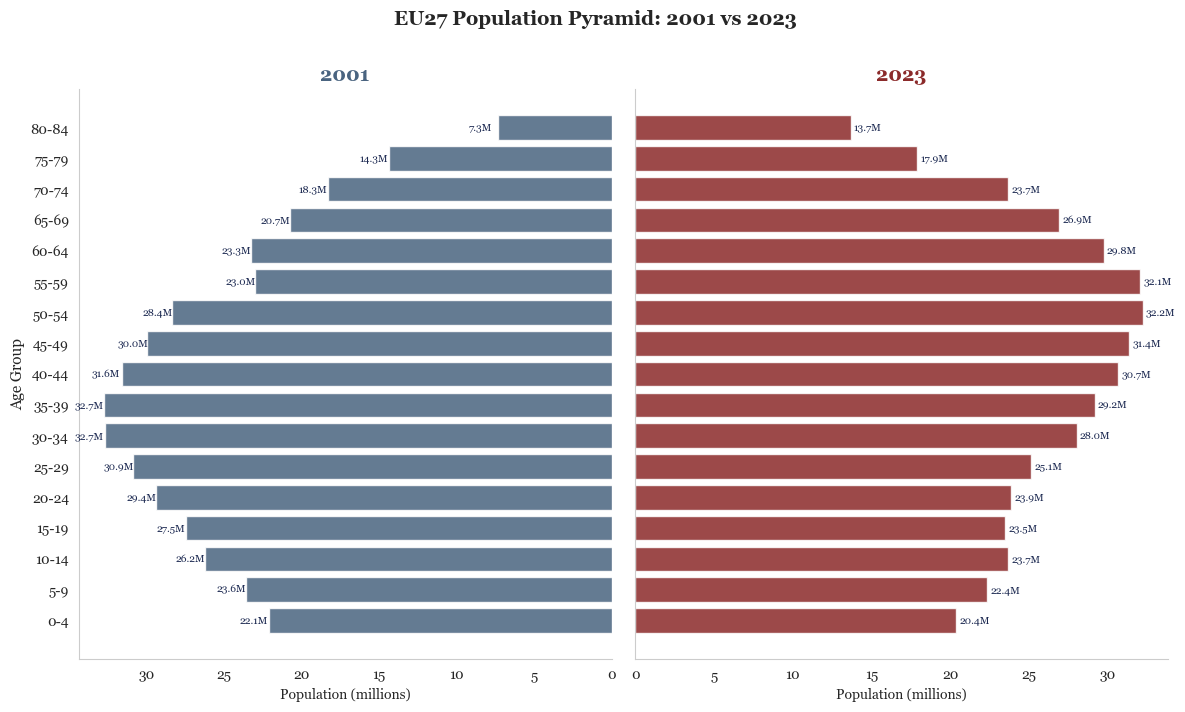

✅ Chart 3 saved


In [24]:
age_labels_ordered = ['0-4','5-9','10-14','15-19','20-24','25-29',
                      '30-34','35-39','40-44','45-49','50-54','55-59',
                      '60-64','65-69','70-74','75-79','80-84']

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
fig.patch.set_alpha(0)

for idx, (yr, color, ax) in enumerate([(2001, C_MID, axes[0]), (2023, C_RED, axes[1])]):
    sub = pyramid_long[pyramid_long['year']==yr].set_index('age_label')
    vals = [sub.loc[a,'population_M'] if a in sub.index else 0 for a in age_labels_ordered]
    ax.barh(age_labels_ordered, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(str(yr), fontsize=14, fontweight='bold', color=color)
    ax.set_xlabel('Population (millions)', fontsize=10)
    ax.patch.set_alpha(0)
    ax.grid(False)
    if idx == 0: ax.invert_xaxis()
    for i, v in enumerate(vals):
        x_pos = v + 0.2 if idx == 1 else v + 1.9
        ax.text(x_pos, i, f'{v:.1f}M', va='center', ha='left', fontsize=7.5, color=C_DARK)

axes[0].set_ylabel('Age Group', fontsize=11)
fig.suptitle('EU27 Population Pyramid: 2001 vs 2023', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Grafici_Draft/03_population_pyramid.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
print('✅ Chart 3 saved')

## Fertility Rate Bar Chart — EU27 Countries (2022)

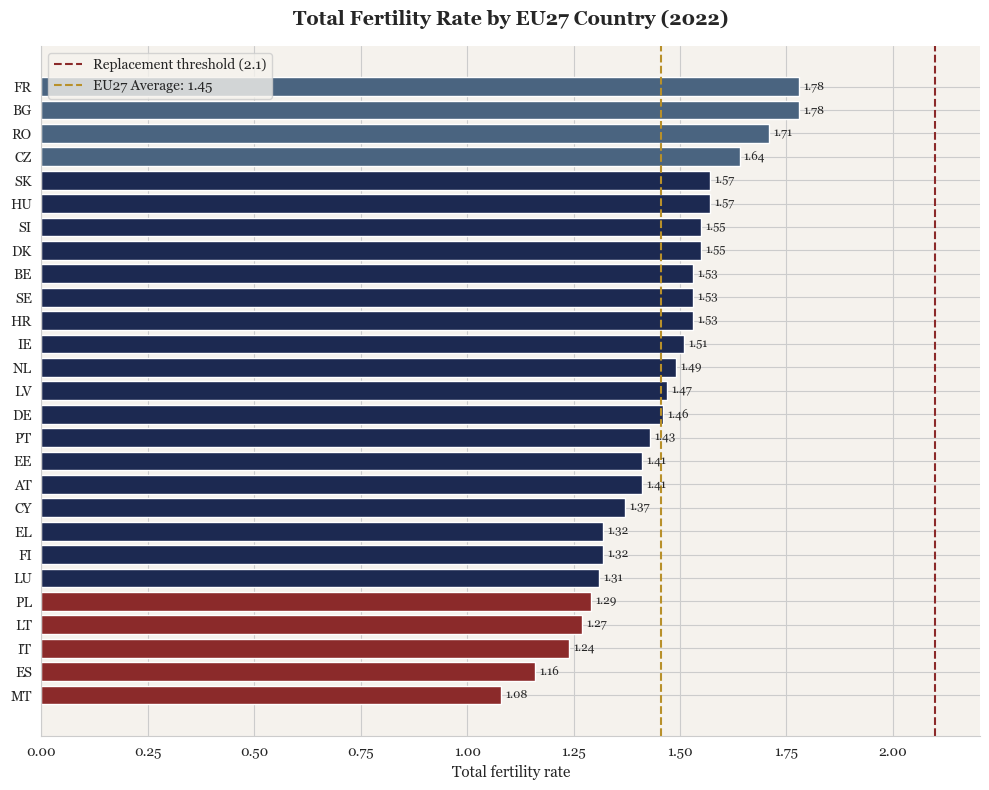

✅ Chart 4 saved


In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
fert_sorted = fert_2022.sort_values('fertility_rate', ascending=True)
colors_f = [C_RED if v < 1.3 else C_DARK if v < 1.6 else C_MID for v in fert_sorted['fertility_rate']]
bars = ax.barh(fert_sorted['geo'], fert_sorted['fertility_rate'], color=colors_f, edgecolor='white')
ax.axvline(x=2.1, color=C_RED, linestyle='--', linewidth=1.5, label='Replacement threshold (2.1)')
ax.axvline(x=fert_2022['fertility_rate'].mean(), color=C_GOLD, linestyle='--', linewidth=1.5,
           label=f'EU27 Average: {fert_2022["fertility_rate"].mean():.2f}')
ax.set_xlabel('Total fertility rate', fontsize=11)
ax.set_title('Total Fertility Rate by EU27 Country (2022)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
for bar, val in zip(bars, fert_sorted['fertility_rate']):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('Grafici_Draft/04_fertility_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved')

## Fertility Rate Trend — EU27 1960–2022

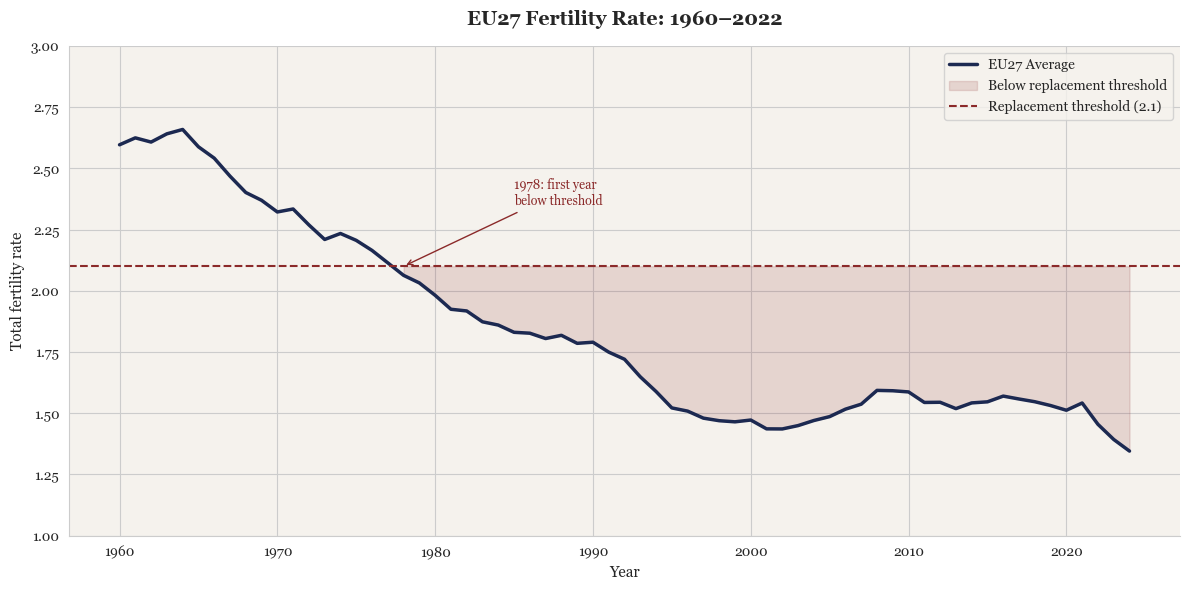

✅ Chart 5 saved


In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
eu27_fert = pd.read_csv('Dataset3/fertility_eu27_trend.csv')
ax.plot(eu27_fert['year'], eu27_fert['fertility_rate'], color=C_DARK, linewidth=2.5, label='EU27 Average')
ax.fill_between(eu27_fert['year'], eu27_fert['fertility_rate'], 2.1,
                where=(eu27_fert['fertility_rate'] < 2.1), alpha=0.15, color=C_RED,
                label='Below replacement threshold')
ax.axhline(y=2.1, color=C_RED, linestyle='--', linewidth=1.5, label='Replacement threshold (2.1)')
ax.annotate('1978: first year\nbelow threshold', xy=(1978, 2.1), xytext=(1985, 2.35),
            arrowprops=dict(arrowstyle='->', color=C_RED), fontsize=9, color=C_RED)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total fertility rate', fontsize=11)
ax.set_title('EU27 Fertility Rate: 1960–2022', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(1.0, 3.0)
plt.tight_layout()
plt.savefig('Grafici_Draft/05_fertility_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 5 saved')

## Life Expectancy Bar Chart — EU27 Countries (2024)

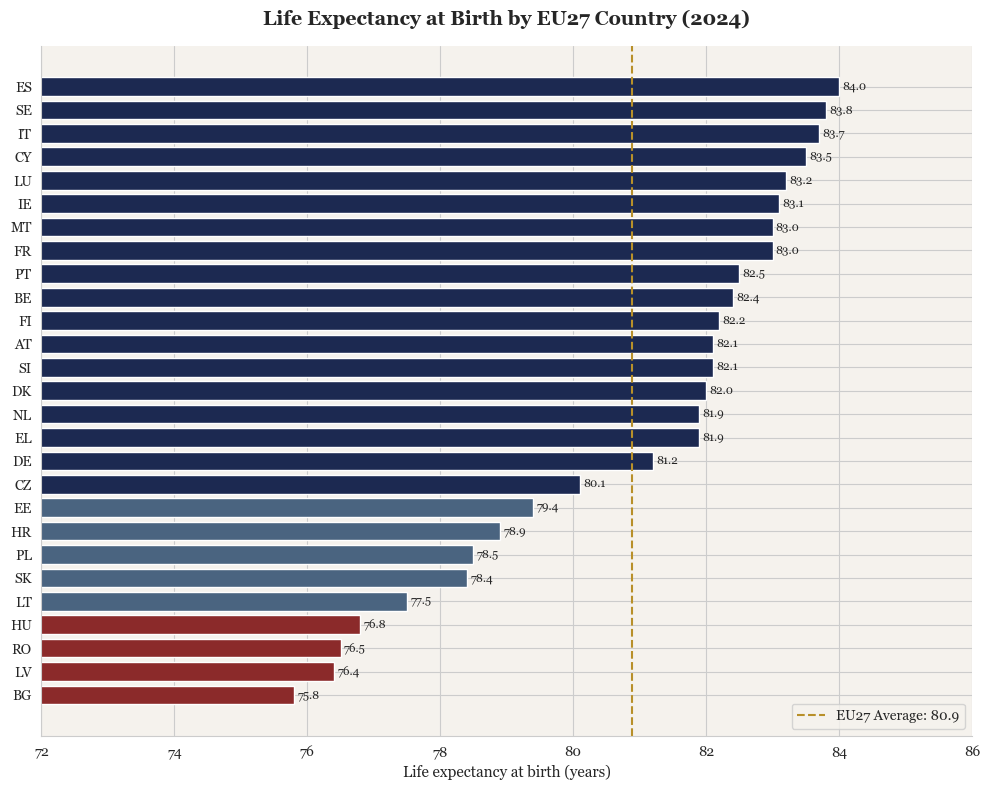

✅ Chart 6 saved


In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
life_sorted = latest_life.sort_values('life_expectancy', ascending=True)
colors_l = [C_RED if v < 77 else C_MID if v < 80 else C_DARK for v in life_sorted['life_expectancy']]
bars = ax.barh(life_sorted['geo'], life_sorted['life_expectancy'], color=colors_l, edgecolor='white')
ax.axvline(x=latest_life['life_expectancy'].mean(), color=C_GOLD, linestyle='--', linewidth=1.5,
           label=f'EU27 Average: {latest_life["life_expectancy"].mean():.1f}')
ax.set_xlabel('Life expectancy at birth (years)', fontsize=11)
ax.set_title('Life Expectancy at Birth by EU27 Country (2024)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_xlim(72, 86)
for bar, val in zip(bars, life_sorted['life_expectancy']):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('Grafici_Draft/06_life_expectancy_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 6 saved')

## Pension Expenditure Bar Chart — EU27 Countries (2023)

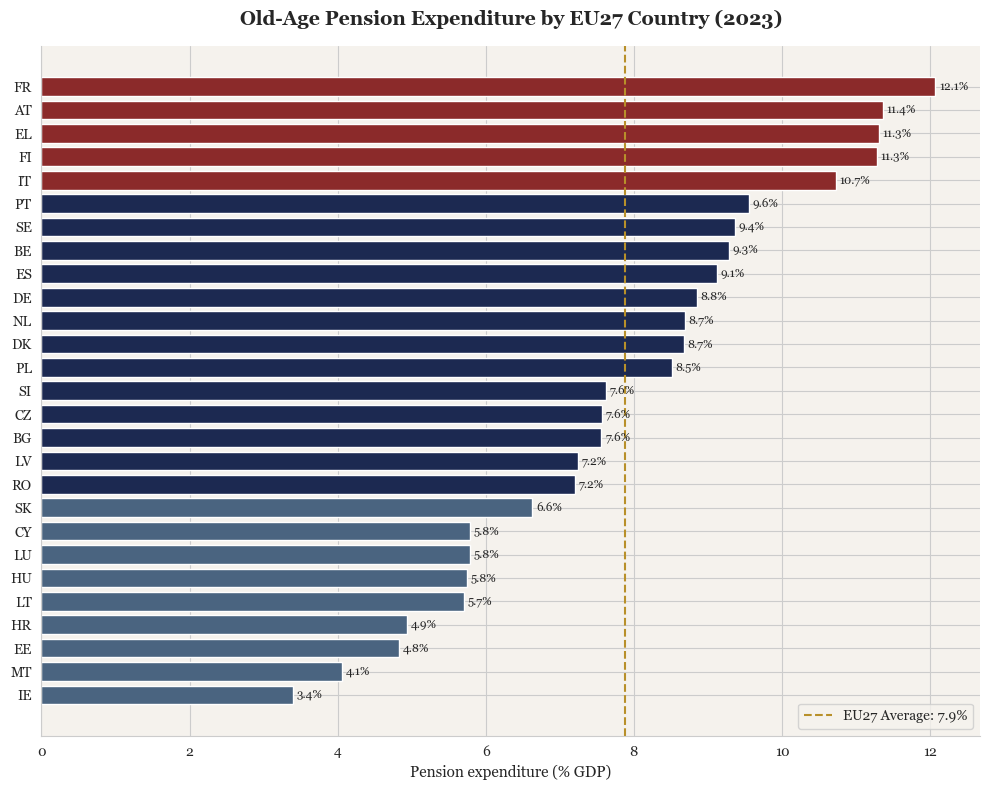

✅ Chart 7 saved


In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
pens_sorted = latest_pension.sort_values('pension_pct_gdp', ascending=True)
colors_p = [C_RED if v > 10 else C_DARK if v > 7 else C_MID for v in pens_sorted['pension_pct_gdp']]
bars = ax.barh(pens_sorted['geo'], pens_sorted['pension_pct_gdp'], color=colors_p, edgecolor='white')
ax.axvline(x=latest_pension['pension_pct_gdp'].mean(), color=C_GOLD, linestyle='--', linewidth=1.5,
           label=f'EU27 Average: {latest_pension["pension_pct_gdp"].mean():.1f}%')
ax.set_xlabel('Pension expenditure (% GDP)', fontsize=11)
ax.set_title('Old-Age Pension Expenditure by EU27 Country (2023)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
for bar, val in zip(bars, pens_sorted['pension_pct_gdp']):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('Grafici_Draft/07_pension_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 7 saved')

## Dot Plot — Natural Growth vs Net Migration (2024)

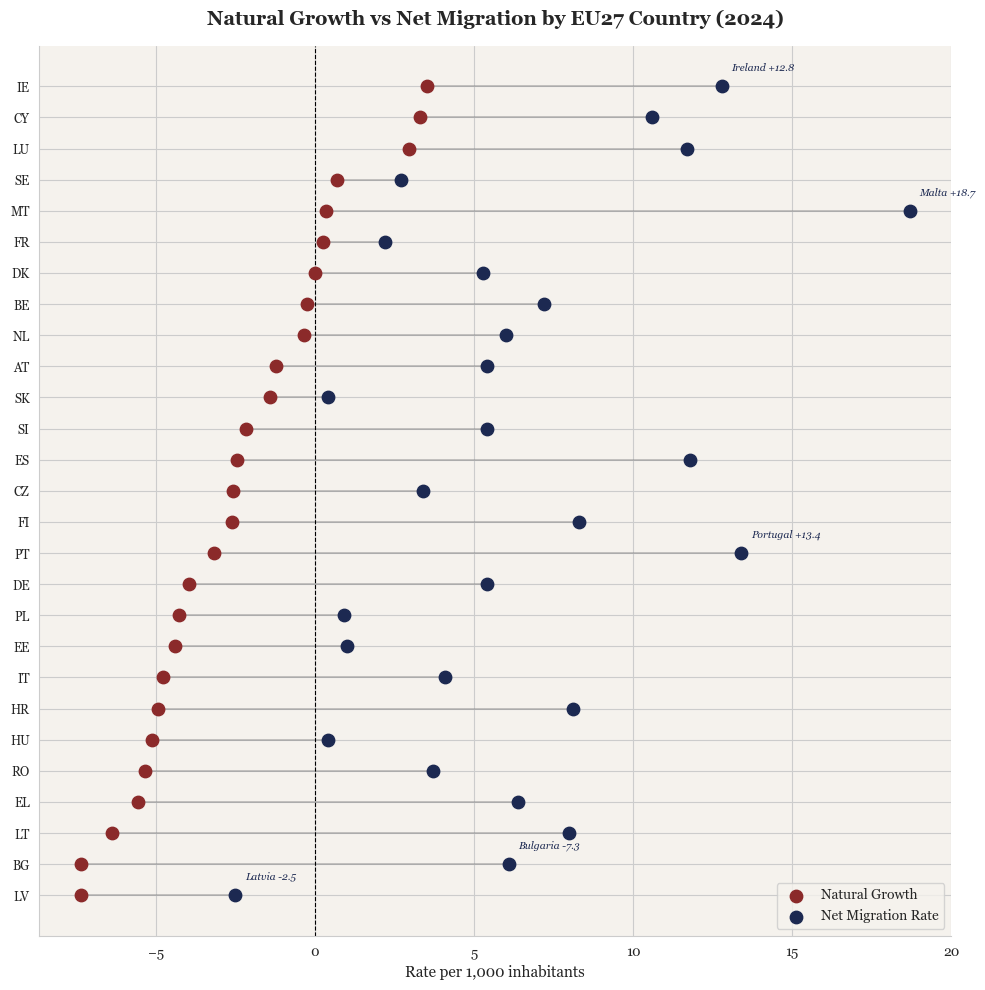

✅ Chart 8 saved


In [29]:
fig, ax = plt.subplots(figsize=(10, 10))
demo_sorted = snapshot_demo.sort_values('natural_growth_rate', ascending=True)
y_pos = range(len(demo_sorted))

for i, (_, row) in enumerate(demo_sorted.iterrows()):
    ax.plot([row['natural_growth_rate'], row['net_migration_rate']], [i, i],
            color='gray', linewidth=1.2, alpha=0.5, zorder=1)

ax.scatter(demo_sorted['natural_growth_rate'], list(y_pos), color=C_RED, s=80, zorder=3, label='Natural Growth')
ax.scatter(demo_sorted['net_migration_rate'],   list(y_pos), color=C_DARK, s=80, zorder=3, label='Net Migration Rate')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(demo_sorted['geo'], fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

annotate = {'MT':'Malta +18.7','LV':'Latvia -2.5','PT':'Portugal +13.4','IE':'Ireland +12.8','BG':'Bulgaria -7.3'}
for i, (_, row) in enumerate(demo_sorted.iterrows()):
    if row['geo'] in annotate:
        ax.annotate(annotate[row['geo']], xy=(row['net_migration_rate'], i),
                    xytext=(row['net_migration_rate']+0.3, i+0.5), fontsize=7.5, color=C_DARK, style='italic')

ax.set_xlabel('Rate per 1,000 inhabitants', fontsize=11)
ax.set_title('Natural Growth vs Net Migration by EU27 Country (2024)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('Grafici_Draft/08_dotplot.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 8 saved')

## Dependency Ratio Bar Chart — EU27 Countries (2025)

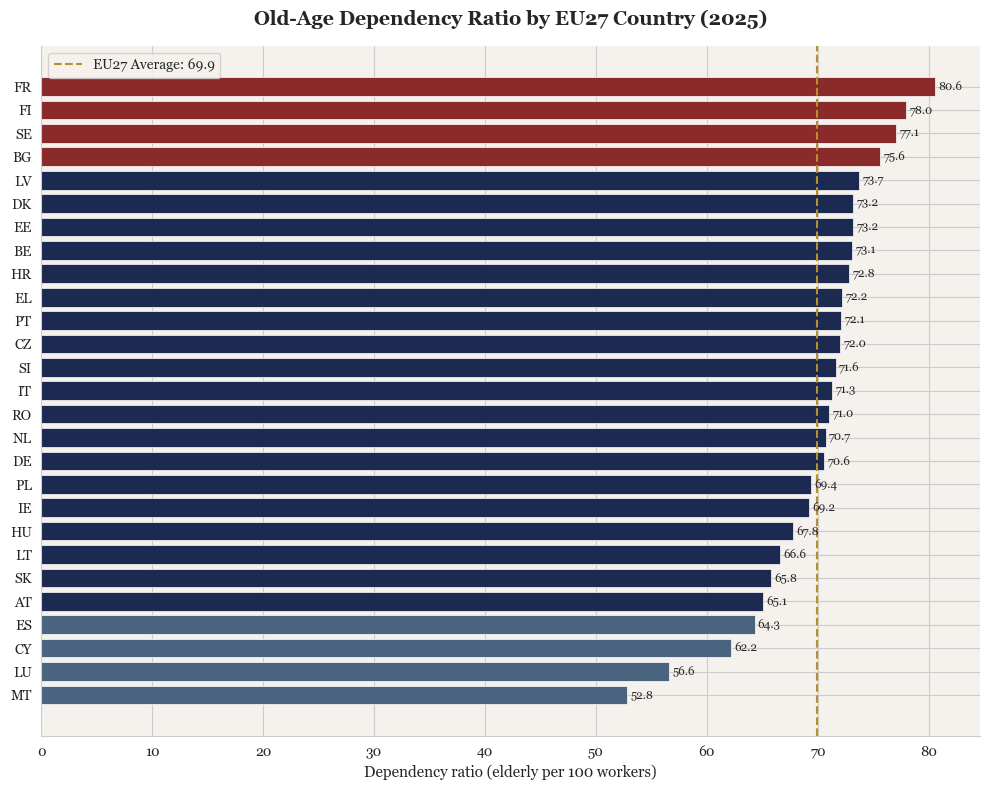

✅ Chart 9 saved


In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
dep_sorted = snapshot.dropna(subset=['dep_ratio']).sort_values('dep_ratio', ascending=True)
colors_dep = [C_RED if v > 75 else C_DARK if v > 65 else C_MID for v in dep_sorted['dep_ratio']]
bars = ax.barh(dep_sorted['geo'], dep_sorted['dep_ratio'], color=colors_dep, edgecolor='white', linewidth=0.5)
ax.axvline(x=dep_sorted['dep_ratio'].mean(), color=C_GOLD, linestyle='--', linewidth=1.5,
           label=f'EU27 Average: {dep_sorted["dep_ratio"].mean():.1f}')
ax.set_xlabel('Dependency ratio (elderly per 100 workers)', fontsize=11)
ax.set_title('Old-Age Dependency Ratio by EU27 Country (2025)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
for bar, val in zip(bars, dep_sorted['dep_ratio']):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('Grafici_Draft/09_dep_ratio_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 9 saved')

## Demographic Scissors — Life Expectancy vs Fertility Rate EU27

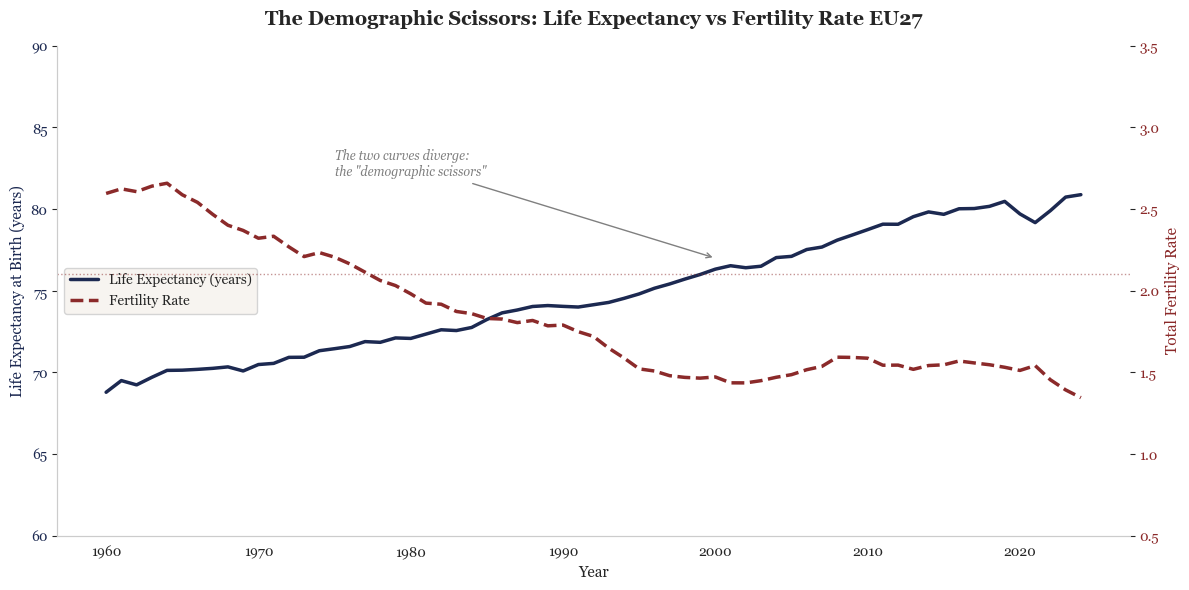

✅ Chart 10 saved


In [31]:
eu27_life = pd.read_csv('Dataset4/life_expectancy_eu27_trend.csv')
eu27_fert = pd.read_csv('Dataset3/fertility_eu27_trend.csv')

fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_alpha(0)
ax1.patch.set_alpha(0)

ax1.plot(eu27_life['year'], eu27_life['life_expectancy'], color=C_DARK, linewidth=2.5, label='Life Expectancy (years)')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Life Expectancy at Birth (years)', fontsize=11, color=C_DARK)
ax1.tick_params(axis='y', labelcolor=C_DARK)
ax1.set_ylim(60, 90)
ax1.grid(False)

ax2 = ax1.twinx()
ax2.patch.set_alpha(0)
ax2.plot(eu27_fert['year'], eu27_fert['fertility_rate'], color=C_RED, linewidth=2.5, linestyle='--', label='Fertility Rate')
ax2.axhline(y=2.1, color=C_RED, linestyle=':', linewidth=1, alpha=0.5)
ax2.set_ylabel('Total Fertility Rate', fontsize=11, color=C_RED)
ax2.tick_params(axis='y', labelcolor=C_RED)
ax2.set_ylim(0.5, 3.5)
ax2.grid(False)

ax1.annotate('The two curves diverge:\nthe "demographic scissors"',
             xy=(2000, 77), xytext=(1975, 82),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray', style='italic')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=10, loc='center left')
ax1.set_title('The Demographic Scissors: Life Expectancy vs Fertility Rate EU27', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('Grafici_Draft/10_demographic_scissors.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
print('✅ Chart 10 saved')

## EU Maps — Median Age, Fertility Rate, Natural Growth & Net Migration

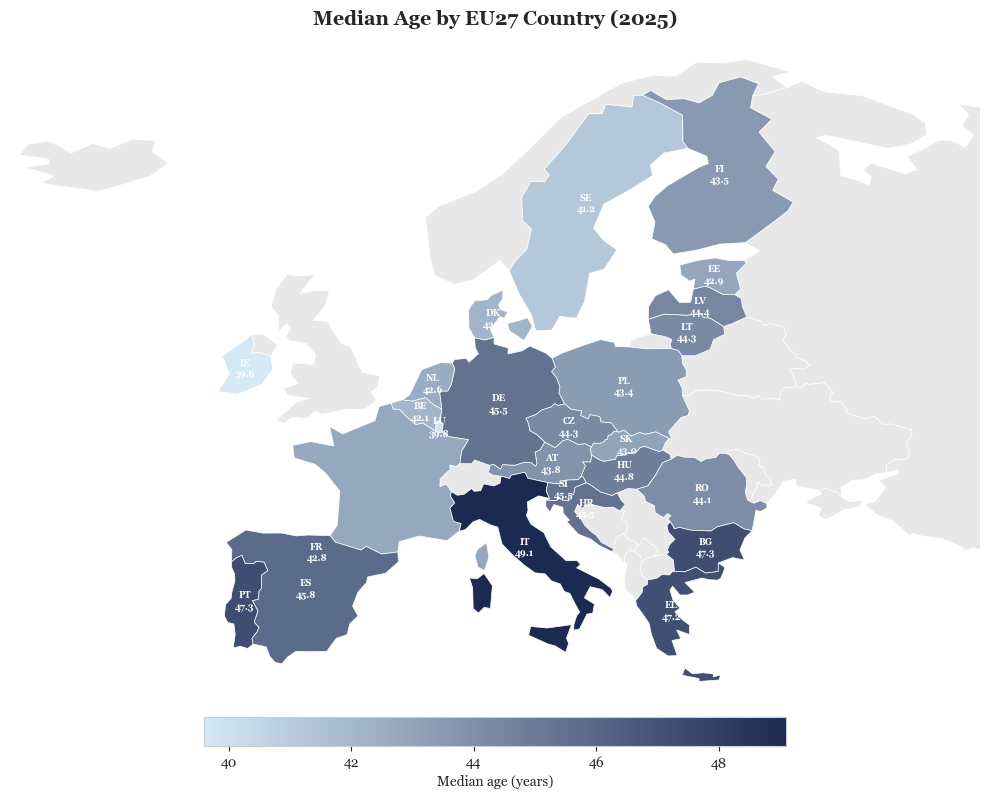

✅ Grafici_Draft/Mappe/map1_median_age.png saved


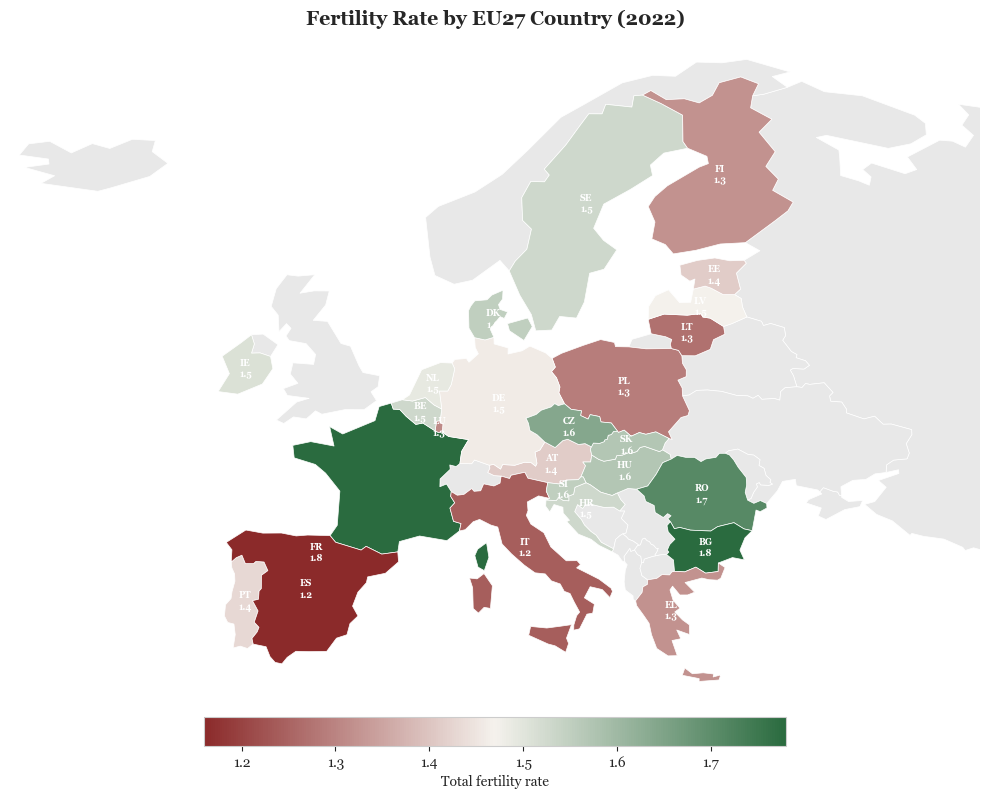

✅ Grafici_Draft/Mappe/map2_fertility.png saved


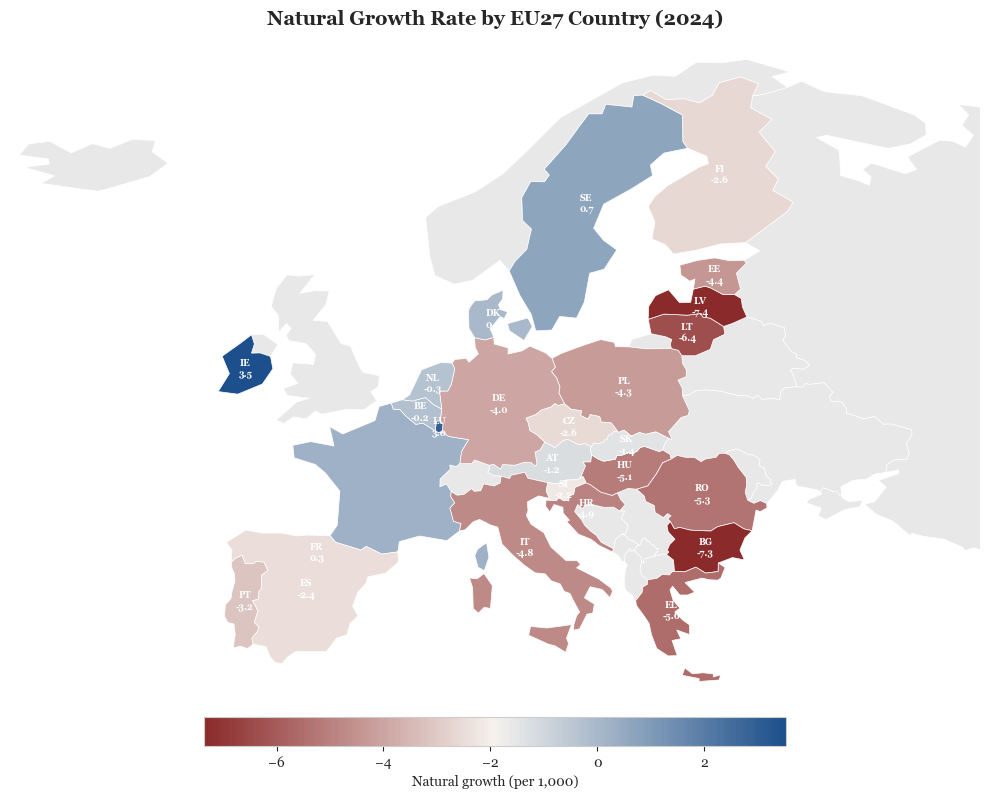

✅ Grafici_Draft/Mappe/map3_natural_growth.png saved


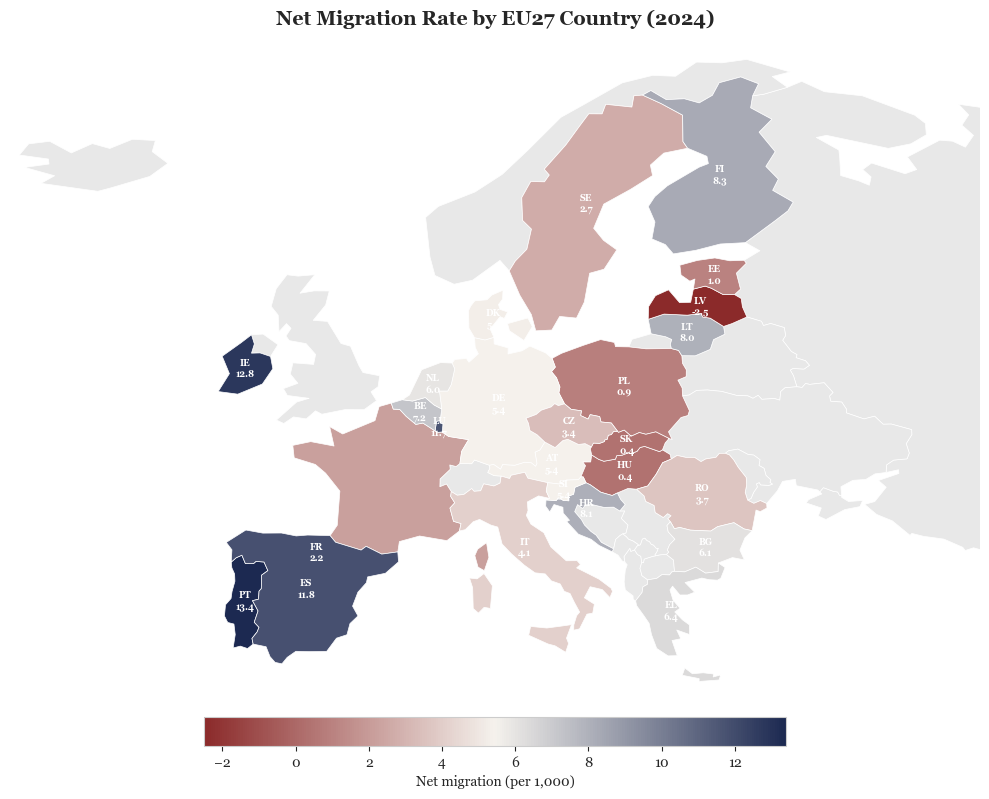

✅ Grafici_Draft/Mappe/map4_migration.png saved


In [32]:
import geopandas as gpd

url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(url)
europe = world[world['CONTINENT'] == 'Europe'].copy()
iso_map = {
    'AUT':'AT','BEL':'BE','BGR':'BG','CYP':'CY','CZE':'CZ','DEU':'DE','DNK':'DK',
    'EST':'EE','GRC':'EL','ESP':'ES','FIN':'FI','FRA':'FR','HRV':'HR','HUN':'HU',
    'IRL':'IE','ITA':'IT','LTU':'LT','LUX':'LU','LVA':'LV','MLT':'MT','NLD':'NL',
    'POL':'PL','PRT':'PT','ROU':'RO','SWE':'SE','SVN':'SI','SVK':'SK'
}
europe['geo'] = europe['ADM0_A3'].map(iso_map)
XLIM, YLIM = (-25, 45), (34, 72)

cmap_age    = LinearSegmentedColormap.from_list('age',    ['#D4E8F5','#1C2951'])
cmap_fert   = LinearSegmentedColormap.from_list('fert',   ['#8B2A2A','#F5F2ED','#2A6B3F'])
cmap_growth = LinearSegmentedColormap.from_list('growth', ['#8B2A2A','#F5F2ED','#1C4F8B'])
cmap_mig    = LinearSegmentedColormap.from_list('mig',    ['#8B2A2A','#F5F2ED','#1C2951'])

def plot_map(data_col, merge_df, cmap, label, title, filename):
    fig, ax = plt.subplots(figsize=(10, 10))
    merged = europe.merge(merge_df, on='geo', how='left')
    europe[europe['geo'].isna()].plot(ax=ax, color='#E8E8E8', edgecolor='white', linewidth=0.5)
    merged.dropna(subset=[data_col]).plot(ax=ax, column=data_col, cmap=cmap,
        edgecolor='white', linewidth=0.5, legend=True,
        legend_kwds={'label': label, 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02})
    for _, row in merged.dropna(subset=[data_col]).iterrows():
        try:
            c = row.geometry.centroid
            if XLIM[0] < c.x < XLIM[1] and YLIM[0] < c.y < YLIM[1]:
                ax.text(c.x, c.y, f"{row['geo']}\n{row[data_col]:.1f}",
                        ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')
        except: pass
    ax.set_xlim(XLIM); ax.set_ylim(YLIM); ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ {filename} saved')

plot_map('median_age',          snapshot[['geo','median_age']],           cmap_age,    'Median age (years)',          'Median Age by EU27 Country (2025)',           'Grafici_Draft/Mappe/map1_median_age.png')
plot_map('fertility_rate',      long_fert[long_fert['year']==2022][['geo','fertility_rate']], cmap_fert, 'Total fertility rate',  'Fertility Rate by EU27 Country (2022)',        'Grafici_Draft/Mappe/map2_fertility.png')
plot_map('natural_growth_rate', snapshot_demo[['geo','natural_growth_rate']],cmap_growth,'Natural growth (per 1,000)', 'Natural Growth Rate by EU27 Country (2024)',   'Grafici_Draft/Mappe/map3_natural_growth.png')
plot_map('net_migration_rate',  snapshot_demo[['geo','net_migration_rate']], cmap_mig,   'Net migration (per 1,000)',  'Net Migration Rate by EU27 Country (2024)',    'Grafici_Draft/Mappe/map4_migration.png')

## Natural Growth vs Net Migration — EU27 Historical Trend (1960–2024)

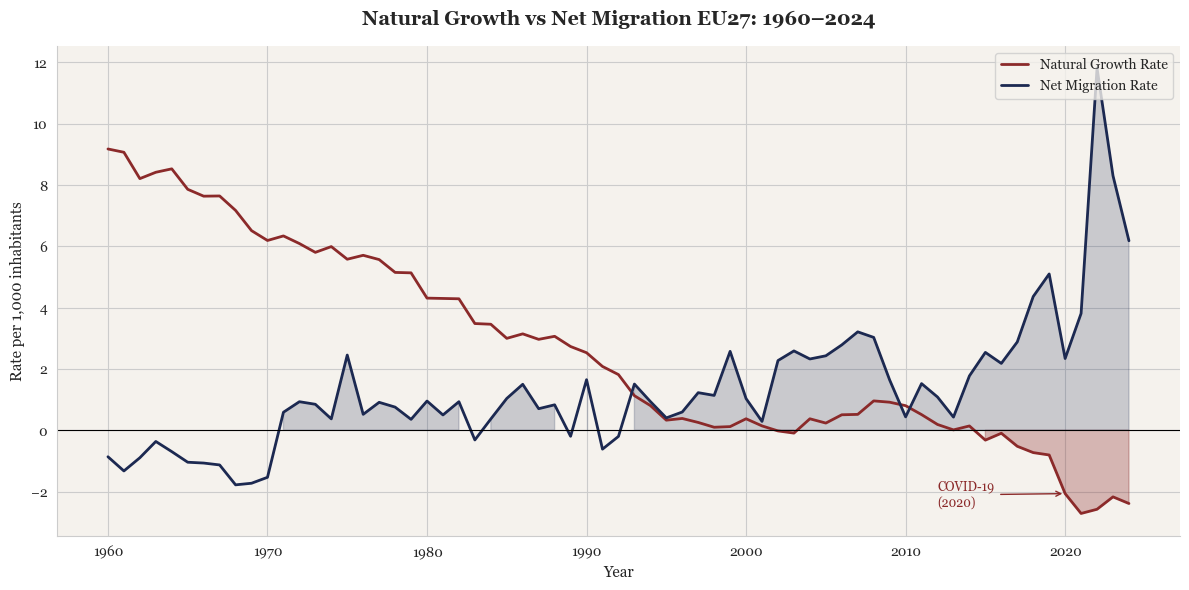

✅ Chart 11 saved


In [33]:
eu27_demo = long_demo.groupby('year')[['natural_growth_rate','net_migration_rate']].mean().reset_index().dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(eu27_demo['year'], eu27_demo['natural_growth_rate'], color=C_RED,  linewidth=2, label='Natural Growth Rate')
ax.plot(eu27_demo['year'], eu27_demo['net_migration_rate'],  color=C_DARK, linewidth=2, label='Net Migration Rate')
ax.fill_between(eu27_demo['year'], eu27_demo['natural_growth_rate'], 0,
                where=(eu27_demo['natural_growth_rate']<0), alpha=0.3, color=C_RED)
ax.fill_between(eu27_demo['year'], eu27_demo['net_migration_rate'], 0,
                where=(eu27_demo['net_migration_rate']>0), alpha=0.2, color=C_DARK)
ax.axhline(y=0, color='black', linewidth=0.8)

covid_val = eu27_demo[eu27_demo['year']==2020]['natural_growth_rate'].values[0]
ax.annotate('COVID-19\n(2020)', xy=(2020, covid_val), xytext=(2012, -2.5),
            arrowprops=dict(arrowstyle='->', color=C_RED), fontsize=9, color=C_RED)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Rate per 1,000 inhabitants', fontsize=11)
ax.set_title('Natural Growth vs Net Migration EU27: 1960–2024', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('Grafici_Draft/11_natural_vs_migration_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Chart 11 saved')

## Export CSVs for Datawrapper

In [34]:
# All CSVs for Datawrapper in one block
exports = {
    '01_median_age_bar':     snapshot[['geo','median_age']].rename(columns={'geo':'Country','median_age':'Median Age'}),
    '04_fertility_bar':      fert_2022[['geo','fertility_rate']].rename(columns={'geo':'Country','fertility_rate':'Fertility Rate'}),
    '05_fertility_trend':    eu27_fert_trend[['year','fertility_rate']].rename(columns={'year':'Year','fertility_rate':'Fertility Rate'}),
    '06_life_expectancy':    latest_life[['geo','life_expectancy']].rename(columns={'geo':'Country','life_expectancy':'Life Expectancy'}),
    '07_pension':            latest_pension[['geo','pension_pct_gdp']].rename(columns={'geo':'Country','pension_pct_gdp':'Pension % GDP'}),
    '08_dotplot':            snapshot_demo[['geo','natural_growth_rate','net_migration_rate']].rename(columns={'geo':'Country','natural_growth_rate':'Natural Growth','net_migration_rate':'Net Migration'}),
    '09_dep_ratio':          snapshot[['geo','dep_ratio']].dropna().rename(columns={'geo':'Country','dep_ratio':'Dependency Ratio'}),
    '11_map_migration':      snapshot_demo[['geo','net_migration_rate']].rename(columns={'geo':'ISO Code','net_migration_rate':'Net Migration Rate'}),
    '12_map_median_age':     snapshot[['geo','median_age']].rename(columns={'geo':'ISO Code','median_age':'Median Age'}),
    '13_natural_vs_migration': eu27_demo[['year','natural_growth_rate','net_migration_rate']].rename(columns={'year':'Year','natural_growth_rate':'Natural Growth Rate','net_migration_rate':'Net Migration Rate'}),
}

# Trend median age (wide format)
highlight_geos = ['IT','DE','FR','ES','BG','IE']
csv2 = df_clean[df_clean['geo'].isin(highlight_geos)][['geo','year','median_age']]
csv2_wide = csv2.pivot(index='year', columns='geo', values='median_age').reset_index()
csv2_wide = csv2_wide.merge(eu27_trend[['year','median_age']].rename(columns={'median_age':'EU27 Average'}), on='year', how='left')
exports['02_median_age_trend'] = csv2_wide

# Pyramid (wide format)
csv3 = pyramid_long[['age_label','year','population_M']].pivot(index='age_label', columns='year', values='population_M').reset_index()
csv3.columns = ['Age Group', '2001', '2023']
csv3['_sort'] = csv3['Age Group'].map({a:i for i,a in enumerate(age_labels_ordered)})
exports['03_pyramid'] = csv3.sort_values('_sort').drop(columns='_sort')

# Forbice index (normalised to 1960=100)
csv10 = eu27_life[['year','life_expectancy']].merge(eu27_fert[['year','fertility_rate']], on='year')
base_l = csv10.loc[csv10['year']==1960,'life_expectancy'].values[0]
base_f = csv10.loc[csv10['year']==1960,'fertility_rate'].values[0]
csv10['Life Expectancy (index)'] = csv10['life_expectancy'] / base_l * 100
csv10['Fertility Rate (index)']  = csv10['fertility_rate']  / base_f * 100
exports['10_forbice_index'] = csv10[['year','Life Expectancy (index)','Fertility Rate (index)']].rename(columns={'year':'Year'})

for name, df_exp in exports.items():
    df_exp.to_csv(f'CSV_Datawrapper/{name}.csv', index=False)

print(f'✅ {len(exports)} CSV files exported to CSV_Datawrapper/')

✅ 13 CSV files exported to CSV_Datawrapper/
